In [ ]:
week1_text_cleaning_eda


In [1]:
print("hello")

hello


In [5]:
from google.colab import files
uploaded = files.upload()

Saving twitter_training[1].csv to twitter_training[1] (1).csv


In [6]:
import os
print(os.listdir())

['.config', 'twitter_training[1].csv', 'twitter_training[1] (1).csv', 'sample_data']


In [8]:
import pandas as pd

df = pd.read_csv('twitter_training[1].csv')
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [9]:
print(df.columns)


Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')


In [10]:
df.head(10)


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
5,2402,Borderlands,Positive,So I spent a few hours making something for fu...
6,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
7,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
8,2402,Borderlands,Positive,So I spent a few hours making something for fu...
9,2402,Borderlands,Positive,2010 So I spent a few hours making something f...


In [13]:
df.columns = ['id', 'topic', 'sentiment', 'text']

In [14]:
df.isnull().sum()

,0
id,0
topic,0
sentiment,0
text,686


In [16]:
df['text'] = df['text'].str.lower()

In [18]:
import re

def clean_text(text):
    return re.sub(r'[^a-zA-Z\s]', '', str(text))

df['text'] = df['text'].apply(clean_text)

In [20]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
df['tokens'] = df['text'].apply(lambda x: x.split())

In [23]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(lambda x: [w for w in x if w not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [24]:
df['clean_text'] = df['tokens'].apply(lambda x: " ".join(x))

In [25]:
df[['text','clean_text']].head()

,text,clean_text
0,i am coming to the borders and i will kill you...,coming borders kill
1,im getting on borderlands and i will kill you all,im getting borderlands kill
2,im coming on borderlands and i will murder you...,im coming borderlands murder
3,im getting on borderlands and i will murder y...,im getting borderlands murder
4,im getting into borderlands and i can murder y...,im getting borderlands murder


In [26]:
from collections import Counter

words = " ".join(df['clean_text']).split()
Counter(words).most_common(10)

[('game', 8066),
 ('im', 4941),
 ('like', 4882),
 ('get', 3941),
 ('one', 3584),
 ('good', 3552),
 ('play', 3414),
 ('really', 3260),
 ('love', 3239),
 ('new', 3210)]

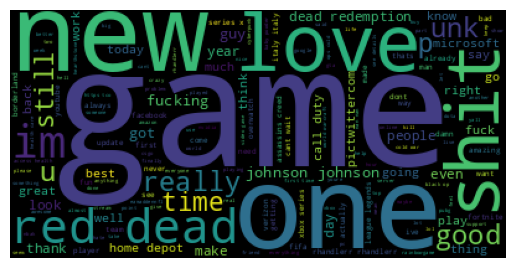

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud().generate(" ".join(df['clean_text']))

plt.imshow(wc)
plt.axis("off")
plt.show()

<Axes: xlabel='sentiment', ylabel='count'>

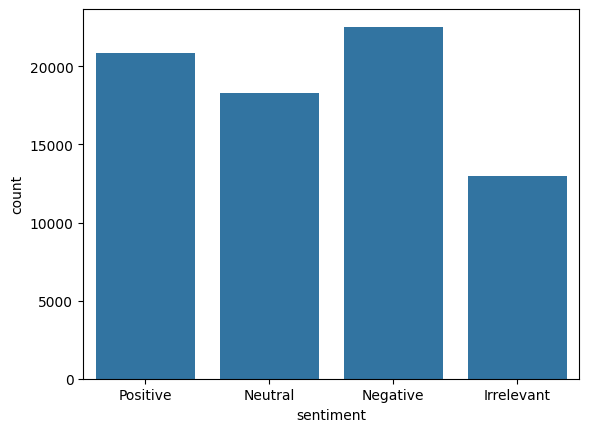

In [28]:
import seaborn as sns

sns.countplot(x='sentiment', data=df)